In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [21]:
from torchvision import datasets, transforms, models
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [6]:
batch_size = 64

In [7]:
data_transforms = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=data_transforms)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = datasets.MNIST(root='./val', train=True, download=True, transform=data_transforms)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 68.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.44MB/s]
100%|██████████| 9.91M/9.91M [00:00<00:00, 57.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.78MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


In [16]:
class VaeAutoencoder(nn.Module):

    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim * 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):

        # (B, 1, 28, 28) → (B, 784)
        x = x.reshape(x.size(0), -1)

        # (B, 784) → (B, 2*latent_dim)
        encoded = self.encoder(x)

        # Split into μ and log variance
        mu, log_var = torch.chunk(encoded, 2, dim=1)

        # Reparameterization trick
        noise = torch.randn_like(mu)
        z = mu + noise * torch.exp(0.5 * log_var)

        # Decode
        x_hat = self.decoder(z)

        return x_hat, mu, log_var


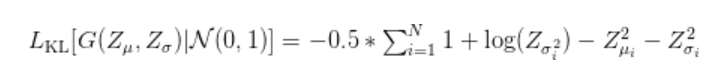

In [25]:
def reconstruction_loss(x_hat, x):
    return F.binary_cross_entropy(x_hat, x)


def kl_loss(mu, log_var):
    return -0.5 * torch.mean(
        torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)
    )

In [18]:
model = VaeAutoencoder(input_dim=784, hidden_dim=256, latent_dim=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epoch = 10

In [27]:
num_epochs = 10

for epoch in range(num_epochs):
    for batch_idx, (data, target) in enumerate(train_loader):

        data = data.to(device)


        data_flat = data.reshape(data.size(0), -1)

        optimizer.zero_grad()

        y_pred, mu, log_var = model(data)


        loss_ = reconstruction_loss(y_pred, data_flat) + kl_loss(mu, log_var)

        loss_.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print(
                f"Epoch: {epoch} | "
                f"batch_idx: {batch_idx} | "
                f"loss: {loss_.item():.4f}"
            )

Epoch: 0 | batch_idx: 0 | loss: 0.2609
Epoch: 0 | batch_idx: 100 | loss: 0.2634
Epoch: 0 | batch_idx: 200 | loss: 0.2587
Epoch: 0 | batch_idx: 300 | loss: 0.2568
Epoch: 0 | batch_idx: 400 | loss: 0.2604
Epoch: 0 | batch_idx: 500 | loss: 0.2617
Epoch: 0 | batch_idx: 600 | loss: 0.2620
Epoch: 0 | batch_idx: 700 | loss: 0.2572
Epoch: 0 | batch_idx: 800 | loss: 0.2568
Epoch: 0 | batch_idx: 900 | loss: 0.2664
Epoch: 1 | batch_idx: 0 | loss: 0.2602
Epoch: 1 | batch_idx: 100 | loss: 0.2569
Epoch: 1 | batch_idx: 200 | loss: 0.2630
Epoch: 1 | batch_idx: 300 | loss: 0.2592
Epoch: 1 | batch_idx: 400 | loss: 0.2497
Epoch: 1 | batch_idx: 500 | loss: 0.2724
Epoch: 1 | batch_idx: 600 | loss: 0.2561
Epoch: 1 | batch_idx: 700 | loss: 0.2601
Epoch: 1 | batch_idx: 800 | loss: 0.2725
Epoch: 1 | batch_idx: 900 | loss: 0.2740
Epoch: 2 | batch_idx: 0 | loss: 0.2672
Epoch: 2 | batch_idx: 100 | loss: 0.2640
Epoch: 2 | batch_idx: 200 | loss: 0.2468
Epoch: 2 | batch_idx: 300 | loss: 0.2661
Epoch: 2 | batch_idx: 